[ DATA ]
       income  loan_amount  credit_score  employment_years       age  target
0    1.129324    -0.867338     -0.319374          0.462295  0.870768       1
1   -0.828194     2.897921      2.317431          2.233074  3.012844       1
2   -0.495866    -1.463371      0.015689          2.050568 -2.438295       0
3    0.618687    -1.488682     -0.339132          1.389235  1.906874       1
4    0.204549    -1.029105     -0.352192          0.632037  1.203497       1
..        ...          ...           ...               ...       ...     ...
295  2.003407    -0.384978     -1.149024         -2.670330 -1.677257       0
296 -0.086845    -0.062418      0.050646          0.247759  0.282821       1
297 -1.561807     0.211829      0.245717          0.319612 -0.615931       1
298  0.059142     1.689580      1.608007          2.023522  2.093334       1
299 -0.050423    -2.521088     -0.421667          2.743692  2.819362       1

[300 rows x 6 columns]
[ ACCURACY ]


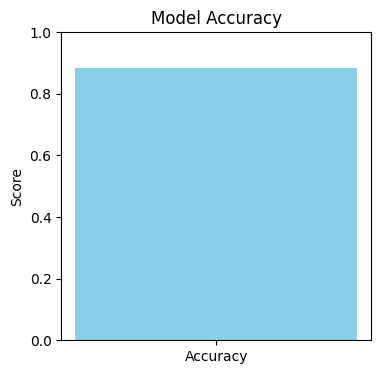

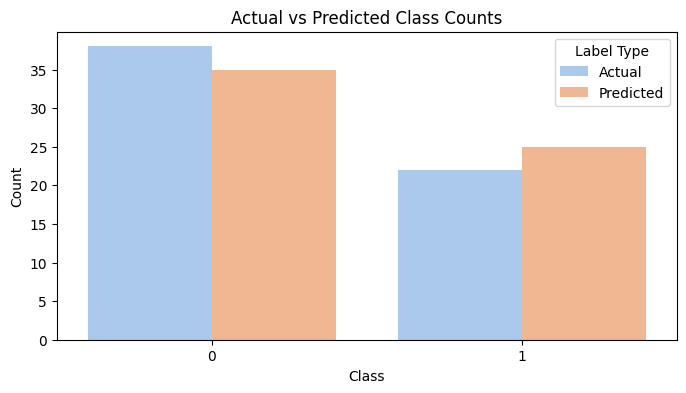

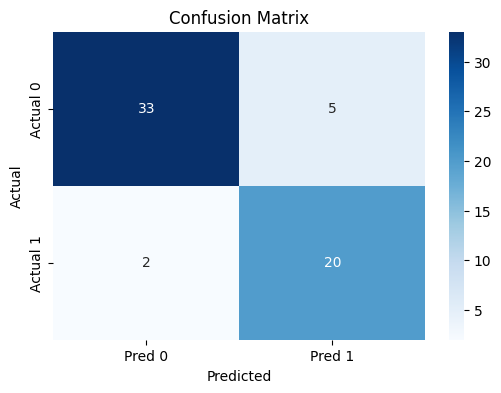

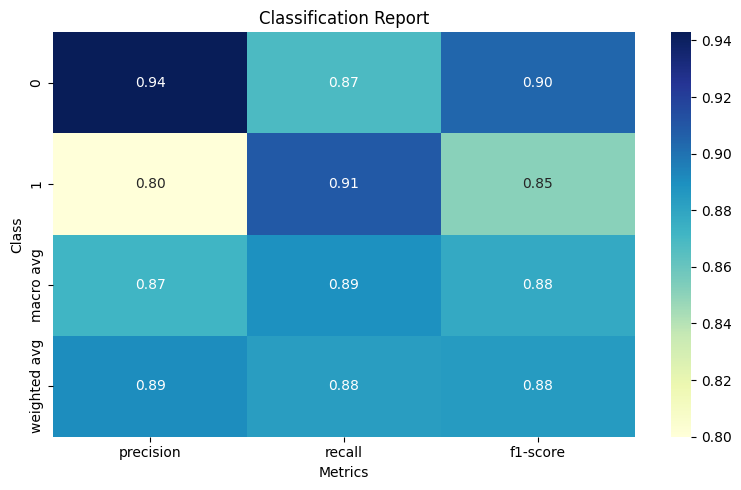

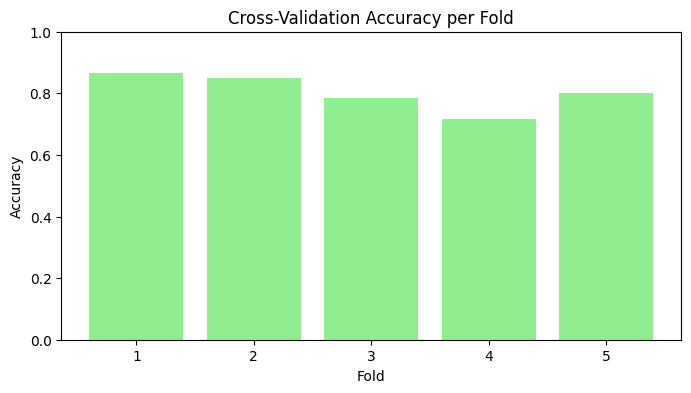

In [2]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

# load & prepare data
data = pd.read_csv('../../CSV/loan_approval_prediction.csv')
X = data.drop(columns='target')
y = data['target']

print("[ DATA ]")
print(data)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# test model by making predictions
predictions = model.predict(X_test)

# evaluate model
accuracy = accuracy_score(y_test, predictions)

# save model
joblib.dump(model, 'models/loan_approval_predictor[DT].joblib')

# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()


# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report = classification_report(y_test, predictions, output_dict=True)

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=5)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.show()